In [ ]:
import pandas as pd
import json
from pathlib import Path
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import roc_curve, precision_recall_curve, auc, precision_score, recall_score


In [10]:
df = pd.read_csv("test_predictions_resnet50_fpn.csv")

In [11]:
df

,file_name,waste_proba,waste_pred
0,13.png,0.929482,1
1,15.png,0.878704,1
2,16.png,0.915256,1
3,17.png,0.968200,1
4,21.png,0.871663,1
...,...,...,...
2602,11696.png,0.121339,0
2603,11697.png,0.803988,1
2604,11700.png,0.131158,0
2605,11701.png,0.269616,0


In [ ]:
train_json = Path("training.json")
test_json = Path("testing.json")

with open(train_json, "r") as f:
    train_data = json.load(f)
with open(test_json, "r") as f:
    test_data = json.load(f)

all_images = train_data.get("images", []) + test_data.get("images", [])

id_mapping = {}
for img in all_images:
    img_id = img.get("id")
    file_name = img.get("file_name", "")
    is_candidate = img.get("is_candidate_location", 0)
    id_mapping[img_id] = {
        "file_name": file_name,
        "is_candidate_location": is_candidate
    }

print(f"Total images in JSONs: {len(all_images)}")
print(f"ID mapping created: {len(id_mapping)} entries")

filename_to_label = {}
for img in all_images:
    fn = img.get("file_name", "")
    is_cand = img.get("is_candidate_location", 0)
    filename_to_label[fn] = is_cand

print(f"Filename->Label mapping: {len(filename_to_label)} entries")
pred_df = pd.read_csv("test_predictions_resnet50_fpn.csv")
pred_df["gt_label"] = pred_df["file_name"].map(filename_to_label)

missing = pred_df["gt_label"].isna().sum()
print(f"\nPredictions without GT label: {missing}/{len(pred_df)}")

eval_df = pred_df.dropna(subset=["gt_label"]).copy()
eval_df["gt_label"] = eval_df["gt_label"].astype(int)

y_true = eval_df["gt_label"].values
y_pred = eval_df["waste_pred"].values
y_prob = eval_df["waste_proba"].values

acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, zero_division=0)
auc = roc_auc_score(y_true, y_prob)
cm = confusion_matrix(y_true, y_pred)

print(f"\n=== Evaluation (n={len(eval_df)}) ===")
print(f"Accuracy: {acc:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC:  {auc:.4f}")
print(f"\nConfusion Matrix:\n{cm}")
print(f"\nClassification Report:\n{classification_report(y_true, y_pred, target_names=['Negative', 'Positive'])}")

# Show sample with GT
print("\n=== Sample Predictions with GT ===")
display(eval_df[["file_name", "waste_proba", "waste_pred", "gt_label"]].head(20))

Total images in JSONs: 11703
ID mapping created: 11703 entries
Filename->Label mapping: 11703 entries

Predictions without GT label: 0/2607

=== Evaluation (n=2607) ===
Accuracy: 0.7499
F1-Score: 0.7226
ROC-AUC:  0.8767

Confusion Matrix:
[[1106  632]
 [  20  849]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.98      0.64      0.77      1738
    Positive       0.57      0.98      0.72       869

    accuracy                           0.75      2607
   macro avg       0.78      0.81      0.75      2607
weighted avg       0.85      0.75      0.76      2607


=== Sample Predictions with GT ===


,file_name,waste_proba,waste_pred,gt_label
0,13.png,0.929482,1,1
1,15.png,0.878704,1,0
2,16.png,0.915256,1,1
3,17.png,0.968200,1,1
4,21.png,0.871663,1,1
5,23.png,0.935860,1,1
6,25.png,0.990451,1,1
7,28.png,0.942843,1,1
8,31.png,0.992838,1,1
9,36.png,0.931490,1,1


In [ ]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 8)

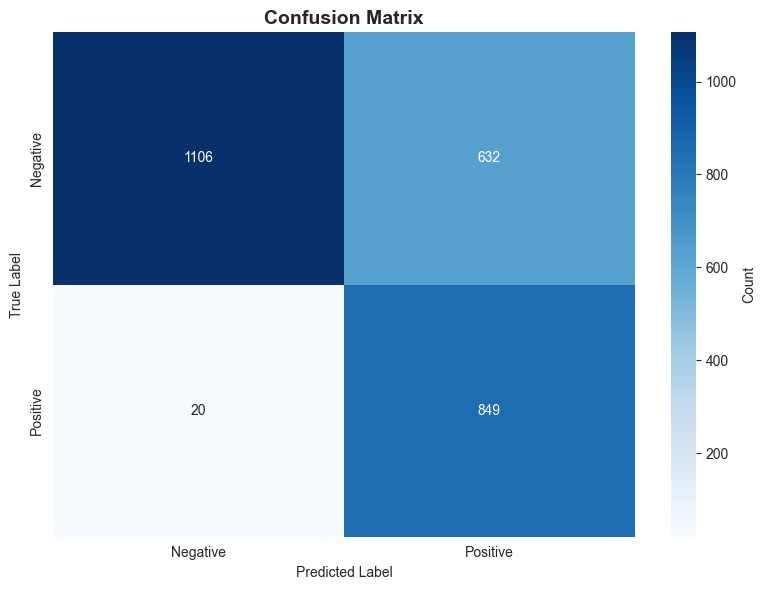

In [ ]:
# 1. Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

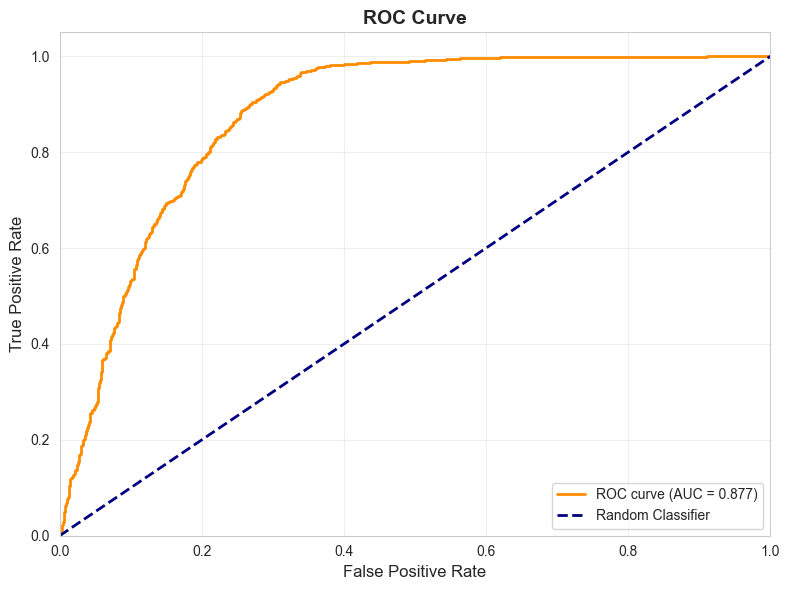

In [15]:
# 2. ROC Curve
plt.figure(figsize=(8, 6))
fpr, tpr, thresholds_roc = roc_curve(y_true, y_prob)
roc_auc_val = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_val:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

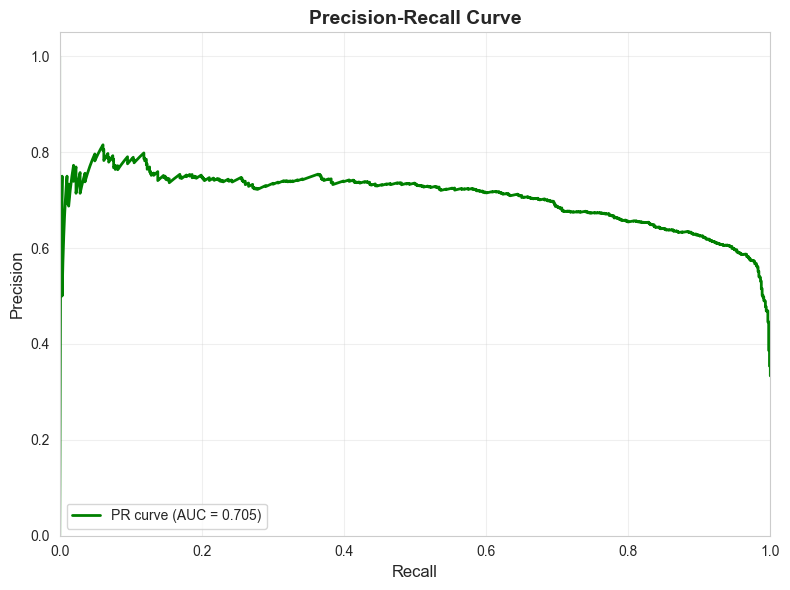

In [16]:
# 3. Precision-Recall Curve
plt.figure(figsize=(8, 6))
precision, recall, thresholds_pr = precision_recall_curve(y_true, y_prob)
pr_auc = auc(recall, precision)
plt.plot(recall, precision, color='green', lw=2, label=f'PR curve (AUC = {pr_auc:.3f})')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

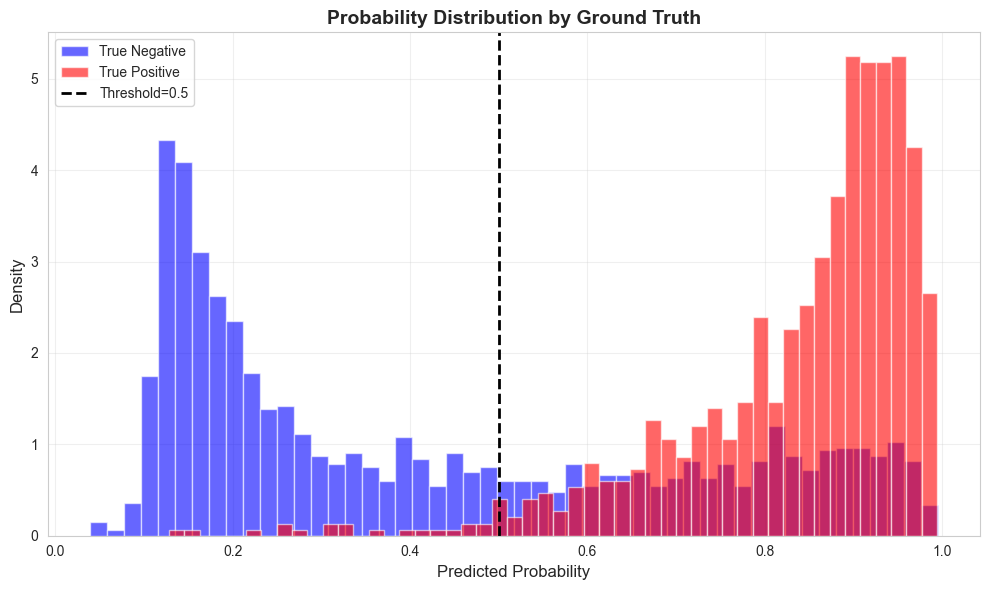

In [17]:
# 4. Probability Distribution by Class
plt.figure(figsize=(10, 6))
pos_probs = eval_df[eval_df['gt_label'] == 1]['waste_proba']
neg_probs = eval_df[eval_df['gt_label'] == 0]['waste_proba']
plt.hist(neg_probs, bins=50, alpha=0.6, label='True Negative', color='blue', density=True)
plt.hist(pos_probs, bins=50, alpha=0.6, label='True Positive', color='red', density=True)
plt.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Threshold=0.5')
plt.xlabel('Predicted Probability', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Probability Distribution by Ground Truth', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

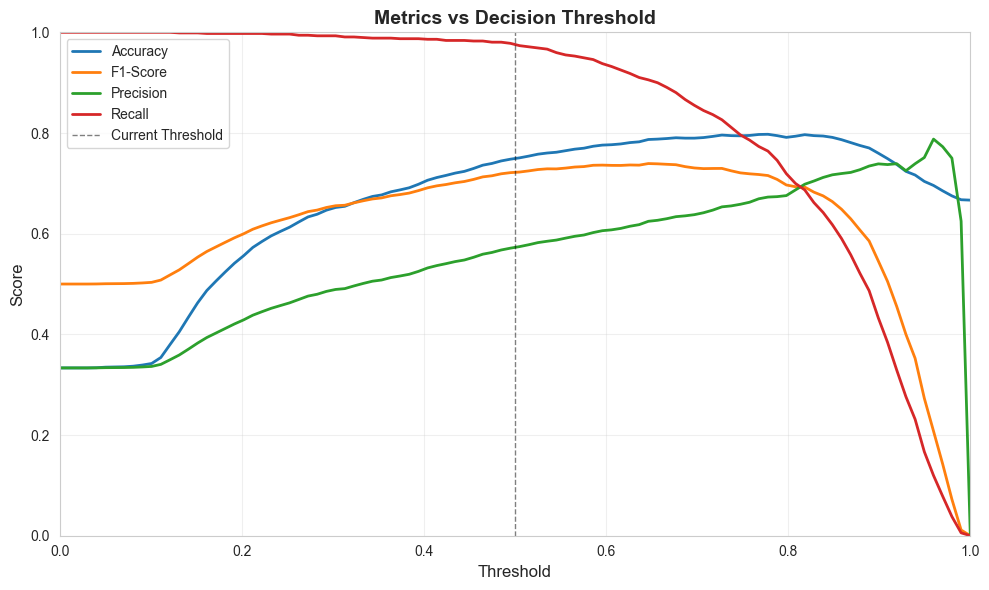

In [29]:
# 5. Metrics vs Threshold
plt.figure(figsize=(10, 6))
thresholds_test = np.linspace(0, 1, 100)
accuracies = []
f1_scores = []
precisions_list = []
recalls_list = []

for thresh in thresholds_test:
    y_pred_thresh = (y_prob >= thresh).astype(int)
    acc_t = accuracy_score(y_true, y_pred_thresh)
    f1_t = f1_score(y_true, y_pred_thresh, zero_division=0)
    prec_t = precision_score(y_true, y_pred_thresh, zero_division=0)
    rec_t = recall_score(y_true, y_pred_thresh, zero_division=0)
    accuracies.append(acc_t)
    f1_scores.append(f1_t)
    precisions_list.append(prec_t)
    recalls_list.append(rec_t)

plt.plot(thresholds_test, accuracies, label='Accuracy', linewidth=2)
plt.plot(thresholds_test, f1_scores, label='F1-Score', linewidth=2)
plt.plot(thresholds_test, precisions_list, label='Precision', linewidth=2)
plt.plot(thresholds_test, recalls_list, label='Recall', linewidth=2)
plt.axvline(x=0.5, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Current Threshold')
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Metrics vs Decision Threshold', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.tight_layout()
plt.show()

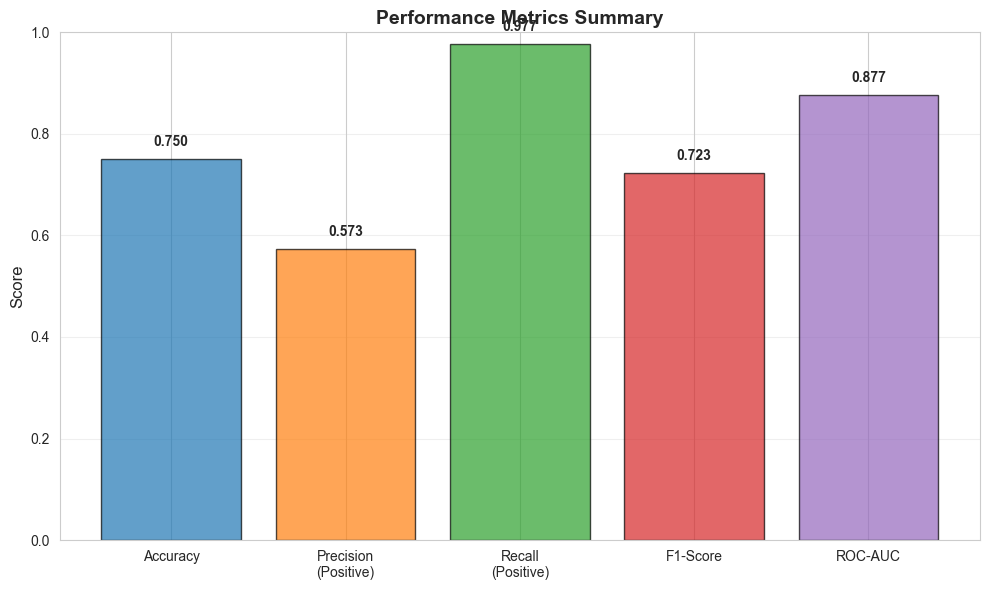

In [ ]:
# 6. Performance Metrics Bar Chart
plt.figure(figsize=(10, 6))
metrics_names = ['Accuracy', 'Precision\n(Positive)', 'Recall\n(Positive)', 'F1-Score', 'ROC-AUC']
prec_pos = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
rec_pos = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
metrics_values = [acc, prec_pos, rec_pos, f1, roc_auc_val]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
bars = plt.bar(metrics_names, metrics_values, color=colors, alpha=0.7, edgecolor='black')
plt.ylabel('Score', fontsize=12)
plt.title('Performance Metrics Summary', fontsize=14, fontweight='bold')
plt.ylim([0, 1])
plt.grid(True, axis='y', alpha=0.3)
for bar, val in zip(bars, metrics_values):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

In [31]:
# Optimal Threshold Analysis
print("=== Optimal Threshold Analysis ===")
best_f1_idx = np.argmax(f1_scores)
best_thresh = thresholds_test[best_f1_idx]
print(f"Threshold for best F1-Score: {best_thresh:.3f}")
print(f"  - Accuracy: {accuracies[best_f1_idx]:.4f}")
print(f"  - F1-Score: {f1_scores[best_f1_idx]:.4f}")
print(f"  - Precision: {precisions_list[best_f1_idx]:.4f}")
print(f"  - Recall: {recalls_list[best_f1_idx]:.4f}")

# Find balanced threshold (closest to equal precision/recall)
balance_diffs = [abs(p - r) for p, r in zip(precisions_list, recalls_list)]
balanced_idx = np.argmin(balance_diffs)
balanced_thresh = thresholds_test[balanced_idx]
print(f"\nBalanced Threshold (Precision ≈ Recall): {balanced_thresh:.3f}")
print(f"  - Accuracy: {accuracies[balanced_idx]:.4f}")
print(f"  - F1-Score: {f1_scores[balanced_idx]:.4f}")
print(f"  - Precision: {precisions_list[balanced_idx]:.4f}")
print(f"  - Recall: {recalls_list[balanced_idx]:.4f}")

=== Optimal Threshold Analysis ===
Threshold for best F1-Score: 0.646
  - Accuracy: 0.7871
  - F1-Score: 0.7393
  - Precision: 0.6246
  - Recall: 0.9056

Balanced Threshold (Precision ≈ Recall): 1.000
  - Accuracy: 0.6667
  - F1-Score: 0.0000
  - Precision: 0.0000
  - Recall: 0.0000
